# Notebook 3: Surface Controls (Experiment 2, Analyses 2B)

Reproduces **Table S3** (non-neural baselines and surface controls)
and **Figure 4** (surface feature analysis).

These controls rule out the possibility that the activation probe is
detecting surface-level lexical features rather than internal knowledge state.

**Data sources:**
- `results/surface_controls.json` — TF-IDF, surface features, grouped CV, year strings
- `results/canonical/experiment_2.json` — Cross-reference values
- `data/questions/*.json` — Question text for independent verification

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

BASE = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..")

with open(os.path.join(BASE, "results/surface_controls.json")) as f:
    controls = json.load(f)

with open(os.path.join(BASE, "results/canonical/experiment_2.json")) as f:
    canonical_exp2 = json.load(f)

print(f"Provenance: {controls['_provenance']}")
print(f"Model: {controls['model']}")
print(f"n_questions: {controls['n_questions']}")
print(f"Original label counts: {controls['label_counts_original']}")

Provenance: Extracted from analysis/experiment_02/surface_form_controls_executed.ipynb (Session 073, 2026-02-27). All values use original (non-model-relative) labels on Mistral 7B question set (n=338, K=210, D=89, C=39).
Model: Mistral-7B-Instruct-v0.3
n_questions: 338
Original label counts: {'K': 210, 'D': 89, 'C': 39}


## 1. Table S3: Non-neural baselines

These classifiers operate on surface features of the question text only,
with no access to model internals. High K-vs-D AUROC from a surface
classifier would undermine the activation probe's claim to detect
internal knowledge state.

Note: Non-neural controls use **original** (non-model-relative) labels
on the Mistral 7B question set (n=338; K=210, D=89, C=39).

In [2]:
baselines = controls["non_neural_baselines"]

print(f"{'Classifier':<25} {'K-vs-D AUROC':>12} {'(std)':>7} "
      f"{'C-vs-D AUROC':>12} {'(std)':>7}")
print("-" * 70)

for name, vals in baselines.items():
    kd = vals["k_vs_d"]
    cd = vals["c_vs_d"]
    print(f"{name:<25} {kd['mean_auroc']:>12.3f} {kd['std_auroc']:>7.3f} "
          f"{cd['mean_auroc']:>12.3f} {cd['std_auroc']:>7.3f}")

# Cross-check against canonical
can_baselines = canonical_exp2["analysis_2b_surface_controls"]
for name in baselines:
    can_vals = can_baselines.get(name, {})
    if "k_vs_d_auroc" in can_vals:
        src = baselines[name]["k_vs_d"]["mean_auroc"]
        can = can_vals["k_vs_d_auroc"]
        assert abs(src - can) < 0.01, f"{name} K-vs-D mismatch: {src} vs {can}"
        print(f"  [{name} K-vs-D cross-check OK]")

Classifier                K-vs-D AUROC   (std) C-vs-D AUROC   (std)
----------------------------------------------------------------------
tfidf_500                        0.596   0.065        0.945   0.048
surface_features_7var            0.440   0.054        0.829   0.091
token_rarity_2var                0.458   0.038        0.610   0.135


## 2. Year-string analysis

C-type questions disproportionately contain year strings (e.g., "2023", "2024")
because they are temporal/contested. This is a known surface confound for
C-vs-D classification, but does NOT affect K-vs-D (the paper's primary contrast).

In [3]:
year_pct = controls["year_string_percentages"]
print(f"Fraction of questions containing a year string (\\b20[12]\\d\\b):")
print(f"  K: {year_pct['K']:.0%}")
print(f"  D: {year_pct['D']:.0%}")
print(f"  C: {year_pct['C']:.0%}")
print()
print(f"Note: {year_pct['_note']}")
print()
print("This explains high C-vs-D AUROC for TF-IDF (year tokens are diagnostic),")
print("but K and D questions have similar year-string rates (2% vs 0%),")
print("so year strings cannot drive K-vs-D classification.")

Fraction of questions containing a year string (\b20[12]\d\b):
  K: 2%
  D: 0%
  C: 64%

Note: Fraction of questions matching \b20[12]\d\b

This explains high C-vs-D AUROC for TF-IDF (year tokens are diagnostic),
but K and D questions have similar year-string rates (2% vs 0%),
so year strings cannot drive K-vs-D classification.


## 3. Surface feature means by label

Mean values of surface text features (character length, word count, digit count,
year presence) across the three label categories.

In [4]:
sf = controls["surface_feature_means"]
print(f"{'Feature':<15} {'K':>8} {'D':>8} {'C':>8}")
print("-" * 42)
for feat in ["length", "word_count", "digit_count", "has_year"]:
    print(f"{feat:<15} {sf['K'][feat]:>8.2f} {sf['D'][feat]:>8.2f} {sf['C'][feat]:>8.2f}")

print()
print("K and D are nearly identical on all surface features,")
print("confirming that surface text properties cannot distinguish them.")

Feature                K        D        C
------------------------------------------
length             80.76    77.70    72.77
word_count         14.03    13.51    12.51
digit_count         1.43     1.43     3.72
has_year            0.02     0.00     0.64

K and D are nearly identical on all surface features,
confirming that surface text properties cannot distinguish them.


## 4. Figure 4: Surface features vs hidden-state AUROC

Visualize the gap between surface-based and hidden-state-based K-vs-D
classification to show the probe detects something beyond surface form.

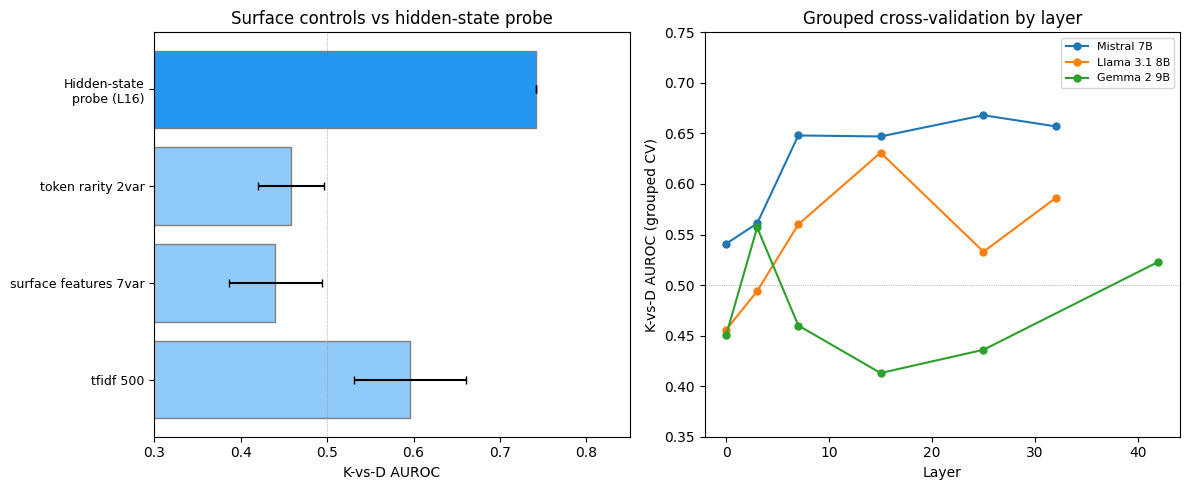

Saved fig4_surface_controls.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Panel A: Non-neural vs hidden-state K-vs-D ---
ax = axes[0]
classifiers = list(baselines.keys())
kd_aurocs = [baselines[c]["k_vs_d"]["mean_auroc"] for c in classifiers]
kd_stds = [baselines[c]["k_vs_d"]["std_auroc"] for c in classifiers]

# Add hidden-state probe best layer from V4 data
with open(os.path.join(BASE, "results/v4_probes.json")) as f:
    v4 = json.load(f)
hidden_best = v4["experiment_2_mlp_vs_linear"]["Mistral-7B"]["best_linear_auroc"]

all_names = [c.replace("_", " ") for c in classifiers] + ["Hidden-state\nprobe (L16)"]
all_aurocs = kd_aurocs + [hidden_best]
all_stds = kd_stds + [0]  # no std for single-point

bar_colors = ["#90CAF9"] * len(classifiers) + ["#2196F3"]
ax.barh(range(len(all_names)), all_aurocs, xerr=all_stds,
        color=bar_colors, edgecolor="gray", capsize=3)
ax.set_yticks(range(len(all_names)))
ax.set_yticklabels(all_names, fontsize=9)
ax.set_xlabel("K-vs-D AUROC")
ax.set_title("Surface controls vs hidden-state probe")
ax.axvline(0.5, color="gray", linewidth=0.5, linestyle=":")
ax.set_xlim(0.3, 0.85)

# --- Panel B: Grouped CV by layer ---
ax = axes[1]
gcv = controls["grouped_cv"]
for model_name in ["Mistral 7B", "Llama 3.1 8B", "Gemma 2 9B"]:
    data = gcv[model_name]
    kd_layers = data["k_vs_d_by_layer"]
    layers = [d["layer"] for d in kd_layers]
    aurocs = [d["auroc"] for d in kd_layers]
    ax.plot(layers, aurocs, "-o", markersize=5, label=model_name)

ax.axhline(0.5, color="gray", linewidth=0.5, linestyle=":")
ax.set_xlabel("Layer")
ax.set_ylabel("K-vs-D AUROC (grouped CV)")
ax.set_title("Grouped cross-validation by layer")
ax.legend(fontsize=8)
ax.set_ylim(0.35, 0.75)

plt.tight_layout()
plt.savefig("fig4_surface_controls.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig4_surface_controls.png")

## 5. Independent verification: recompute surface features from questions

Load raw question files and verify the surface feature means match
the pre-computed values in surface_controls.json.

In [6]:
import re

# Load all questions with original labels
question_files = {
    "K": "data/questions/k_known.json",
    "D2": "data/questions/d2_rare.json",
    "D1": "data/questions/d1_contested.json",
    "D3": "data/questions/d3_degraded.json",
    "C1": "data/questions/c1_temporal.json",
    "C2": "data/questions/c2_obscurity.json",
}

questions_by_label = {"K": [], "D": [], "C": []}
for key, path in question_files.items():
    with open(os.path.join(BASE, path)) as f:
        raw = json.load(f)

    # Files are {"version": ..., "questions": [...]} dicts
    qs = raw["questions"] if isinstance(raw, dict) and "questions" in raw else raw

    # Map construction type to original label
    if key == "K":
        label = "K"
    elif key.startswith("D"):
        label = "D"
    else:
        label = "C"

    for q in qs:
        text = q["text"] if isinstance(q, dict) else q
        questions_by_label[label].append(text)

print("Question counts by original label:")
for label, qs in questions_by_label.items():
    print(f"  {label}: {len(qs)}")

# Verify: K=210, D=89, C=39 (original labels, Mistral question set)
total = sum(len(v) for v in questions_by_label.values())
print(f"  Total: {total}")

# Compute surface features
year_pattern = re.compile(r"\b20[12]\d\b")
for label in ["K", "D", "C"]:
    qs = questions_by_label[label]
    lengths = [len(q) for q in qs]
    word_counts = [len(q.split()) for q in qs]
    digit_counts = [sum(c.isdigit() for c in q) for q in qs]
    has_year = [1 if year_pattern.search(q) else 0 for q in qs]

    print(f"\n{label}: length={np.mean(lengths):.2f}, words={np.mean(word_counts):.2f}, "
          f"digits={np.mean(digit_counts):.2f}, has_year={np.mean(has_year):.2f}")

    # Compare with stored values
    stored = controls["surface_feature_means"][label]
    assert abs(np.mean(lengths) - stored["length"]) < 1.0, f"{label} length mismatch"
    assert abs(np.mean(word_counts) - stored["word_count"]) < 1.0, f"{label} word_count mismatch"
print("\nSurface feature verification: all values match within tolerance.")

Question counts by original label:
  K: 210
  D: 89
  C: 39
  Total: 338

K: length=80.76, words=14.03, digits=1.43, has_year=0.02

D: length=77.70, words=13.51, digits=1.43, has_year=0.00

C: length=72.77, words=12.51, digits=3.72, has_year=0.64

Surface feature verification: all values match within tolerance.
